## 1、帧相减操作

In [4]:
import cv2
import numpy as np

# --- 读图 ---
img1 = cv2.imread("/ai/LKK/0_A_LKK/202509/DIAS/data_2025/20251217_lktest/image_s42_i3.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("/ai/LKK/0_A_LKK/202509/DIAS/data_2025/20251217_lktest/image_s42_i7.png", cv2.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    raise FileNotFoundError("有图像路径读不到（img1 或 img2 为 None），请检查路径/权限/文件名")

# --- 运算：保持高位 ---
sub = np.abs(img2.astype(np.int16) - img1.astype(np.int16))


# # --- 1) 保存“无损原始”16-bit PNG ---
# out16 = "/ai/LKK/0_A_LKK/202509/DIAS/data_2025/20251217_lktest/sub_16bit.png"
# cv2.imwrite(out16, sub.astype(np.uint16))

# --- 2) 另外保存一个“可视化预览”8-bit PNG（仅用于看，不代表原始数据）---
# 用百分位做窗口，避免被极端值影响
lo = 0
hi = np.percentile(sub, 99.5)
hi = max(hi, 1)  # 防止 hi=0

sub8 = np.clip((sub - lo) * (255.0 / (hi - lo)), 0, 255).astype(np.uint8)
out8 = "/ai/LKK/0_A_LKK/202509/DIAS/data_2025/20251217_lktest/sub_s42_37.png"
cv2.imwrite(out8, sub8)

print("sub min/max:", int(sub8.min()), int(sub8.max()), "nonzero:", int(np.count_nonzero(sub8)))
# print("saved:", out16)
print("saved preview:", out8)



sub min/max: 0 255 nonzero: 406979
saved preview: /ai/LKK/0_A_LKK/202509/DIAS/data_2025/20251217_lktest/sub_s42_37.png


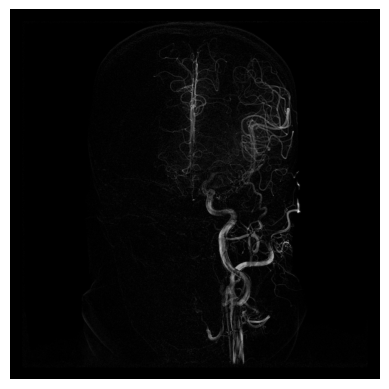

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取两帧图像（灰度）
img1 = cv2.imread("/ai/LKK/0_A_LKK/202509/DIAS/data_2025/20251217_lktest/image_s0_i2.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("/ai/LKK/0_A_LKK/202509/DIAS/data_2025/20251217_lktest/image_s0_i6.png", cv2.IMREAD_GRAYSCALE)

# 关键：防溢出
img1 = img1.astype(np.int16)
img2 = img2.astype(np.int16)

# 逐像素差分 + 绝对值

sub = np.abs(img2 - img1)

# 归一化显示
sub_norm = cv2.normalize(sub, None, 0, 255, cv2.NORM_MINMAX)
sub_norm = sub_norm.astype(np.uint8)

plt.imshow(sub_norm, cmap='gray')
plt.axis('off')
plt.show()


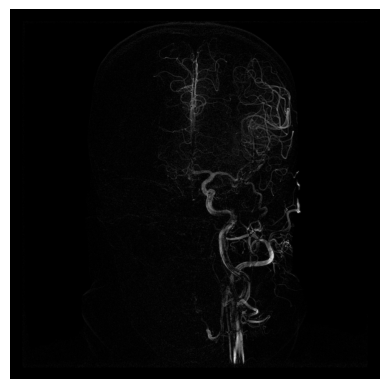

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取两帧图像（灰度）
img1 = cv2.imread("/ai/LKK/0_A_LKK/202509/DIAS/data_2025/20251217_lktest/image_s0_i3.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("/ai/LKK/0_A_LKK/202509/DIAS/data_2025/20251217_lktest/image_s0_i7.png", cv2.IMREAD_GRAYSCALE)

# 关键：防溢出
img1 = img1.astype(np.int16)
img2 = img2.astype(np.int16)

# 逐像素差分 + 绝对值
sub = np.abs(img2 - img1)

# 归一化显示
sub_norm = cv2.normalize(sub, None, 0, 255, cv2.NORM_MINMAX)
sub_norm = sub_norm.astype(np.uint8)

plt.imshow(sub_norm, cmap='gray')
plt.axis('off')
plt.show()


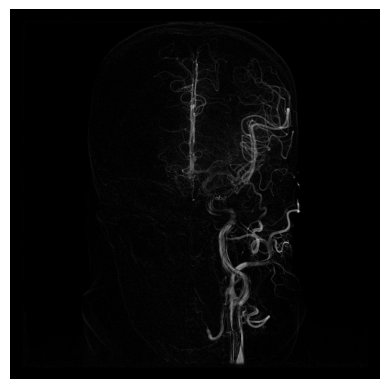

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取两帧图像（灰度）
img1 = cv2.imread("/ai/LKK/0_A_LKK/202509/DIAS/data_2025/20251217_lktest/image_s0_i1.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("/ai/LKK/0_A_LKK/202509/DIAS/data_2025/20251217_lktest/image_s0_i5.png", cv2.IMREAD_GRAYSCALE)

# 关键：防溢出
img1 = img1.astype(np.int16)
img2 = img2.astype(np.int16)

# 逐像素差分 + 绝对值
sub = np.abs(img2 - img1)

# 归一化显示
sub_norm = cv2.normalize(sub, None, 0, 255, cv2.NORM_MINMAX)
sub_norm = sub_norm.astype(np.uint8)

plt.imshow(sub_norm, cmap='gray')
plt.axis('off')
plt.show()


## 2、取max值

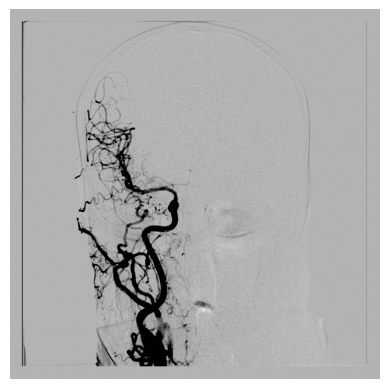

In [2]:
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt

# 读取多帧图像路径
image_paths = sorted(glob.glob("/ai/LKK/0_A_LKK/202509/DIAS/data_2025/20251217_lktest/image_20170103001655_06_*.png"))

imgs = []

for p in image_paths:
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    img = img.astype(np.int16)   # 防止溢出
    imgs.append(img)

# 堆叠成 (N, H, W)
stack = np.stack(imgs, axis=0)

# 逐像素取最大/最小值
mip = np.min(stack, axis=0)

# 归一化显示
mip_norm = cv2.normalize(mip, None, 0, 255, cv2.NORM_MINMAX)
mip_norm = mip_norm.astype(np.uint8)
# 用百分位做窗口，避免被极端值影响
lo = 0
hi = np.percentile(mip, 99.5)
hi = max(hi, 1)  # 防止 hi=0

sub8 = np.clip((mip - lo) * (255.0 / (hi - lo)), 0, 255).astype(np.uint8)
out8 = "/ai/LKK/0_A_LKK/202509/DIAS/data_2025/20251217_lktest/image_20170103001655_06_min_510.png"
cv2.imwrite(out8, sub8)

plt.imshow(mip_norm, cmap='gray')
plt.axis('off')
plt.show()
